# Imports and Load

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
import xgboost as xgb
import mlflow
import re

mlflow.set_tracking_uri("http://localhost:5000")
print("Tracking URI:", mlflow.get_tracking_uri())

mlflow.set_experiment("customer-churn-02")
from mlflow.tracking import MlflowClient
client = MlflowClient()


d:\Documents\ds-ml-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tracking URI: http://localhost:5000


In [2]:
with open('./data/train.csv', 'r') as f:
    df = pd.read_csv(f)

In [3]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
def get_num_and_cat_cols(df):
    numeric_cols = []
    categorical_cols = []

    for col in df.columns:
        if df[col].dtype in ['object', 'str'] or df[col].nunique() == 2:
            categorical_cols.append(col)
        elif df[col].dtype in ['int64', 'float64']:
            if df[col].nunique() < 6:
                categorical_cols.append(col)
            else:
                numeric_cols.append(col)
    
    return (numeric_cols, categorical_cols)

In [5]:
numeric_cols, categorical_cols = get_num_and_cat_cols(df)

print(f"Numeric Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numeric Columns: ['id', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


# 4. Feature engineering

In [24]:
df_features = df.copy()
df_features = df_features.drop("id", axis=1)
numeric_cols_ = numeric_cols.copy()
numeric_cols_.remove("id")
df_features['Churn'] = df_features['Churn'].map({'Yes': 1, 'No': 0})

In [25]:
df_features.iloc[[0]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0


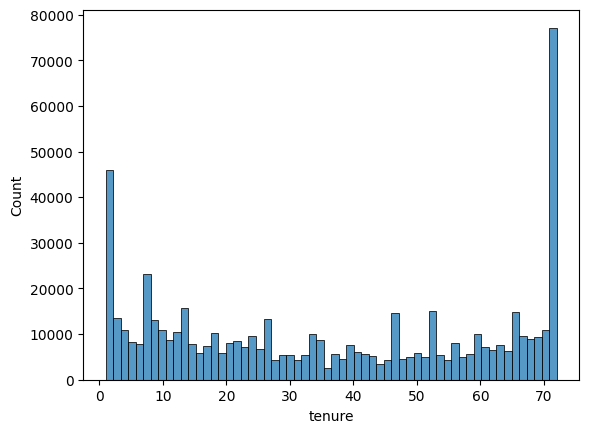

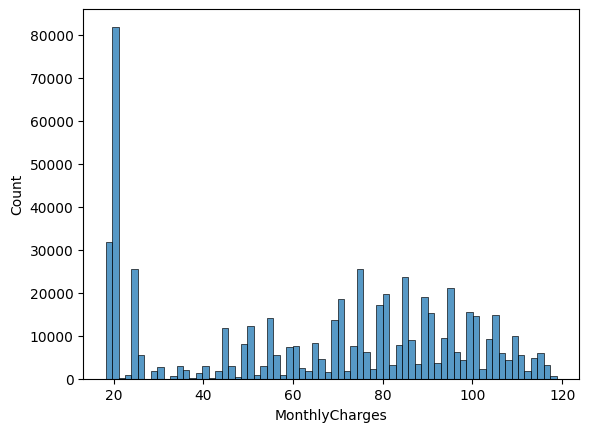

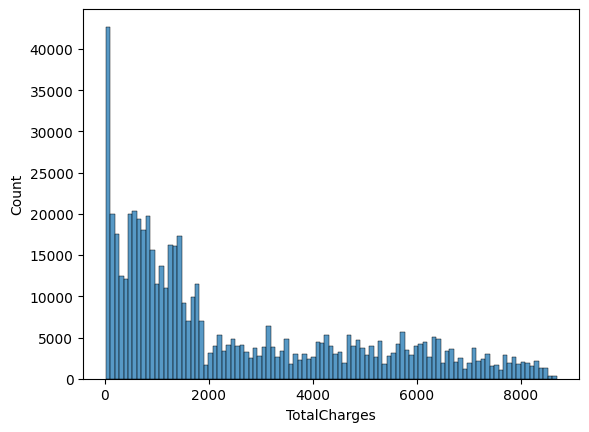

In [26]:
for col in numeric_cols_:
    sns.histplot(df_features, x=col)
    plt.show()

In [27]:
for col in categorical_cols:
    print(col)
    print(df_features[col].unique())

gender
['Male' 'Female']
SeniorCitizen
[0 1]
Partner
['Yes' 'No']
Dependents
['Yes' 'No']
PhoneService
['Yes' 'No']
MultipleLines
['No' 'Yes' 'No phone service']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['Yes' 'No' 'No internet service']
OnlineBackup
['No' 'Yes' 'No internet service']
DeviceProtection
['Yes' 'No' 'No internet service']
TechSupport
['Yes' 'No' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['One year' 'Two year' 'Month-to-month']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
Churn
[0 1]


In [28]:
# Log transformation
for col in numeric_cols_:
    if 0 in df_features[col].unique():
        df_features[f'{col}Log'] = np.log(df_features[col].clip(lower=1e-9))
    else:
        df_features[f'{col}Log'] = np.log(df_features[col])

In [29]:
# Min-max Scaling (normalization)
min_max_scaler = MinMaxScaler()
for col in numeric_cols_:
    df_features[f'{col}Norm'] = min_max_scaler.fit_transform(df_features[[col]])

In [30]:
# Standard Scaling
std_scaler = StandardScaler()
for col in numeric_cols_:
    df_features[f'{col}Std'] = std_scaler.fit_transform(df_features[[col]])

In [31]:
# Binning
df_features[f'tenureBins'] = pd.cut(df_features[f'tenure'], 3, labels=["low", "medium", "high"]).astype("object")
df_features[f'MonthlyChargesBins'] = pd.cut(df_features[f'MonthlyCharges'], 3, labels=["low", "medium", "high"]).astype("object")
df_features[f'TotalChargesBins'] = pd.cut(df_features[f'TotalCharges'], 3, labels=["low", "medium", "high"]).astype("object")

In [ ]:
# Category fraction
l = len(df_features)
for col in categorical_cols:
    if col == "Churn":
        continue
    freq = df_features[col].value_counts()/l
    df_features[f'{col}Frac'] = df_features[col].map(freq)

In [ ]:
# Target encoding
for col in categorical_cols:
    if col == "Churn":
        continue
    df_features[f'{col}ChurnMean'] = df_features.groupby(col)["Churn"].transform('mean')

In [ ]:
# Features interactions
df_features[f'MonthlyChargesAndTenureRatio'] = df_features["MonthlyCharges"] / df_features["tenure"]
df_features[f'TotalChargesAndTenureRantio'] = df_features["TotalCharges"] / df_features["tenure"]
df_features[f'ChargesRatio'] = df_features["TotalCharges"] / df_features["MonthlyCharges"]

In [40]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_features[f'AdditionalInternetServicesCount'] = (df_features[cols] == 'Yes').sum(axis=1)

In [42]:
df_features['BothServices'] = (df_features['PhoneService'] == "Yes") & (df_features['InternetService'] == "Yes").map({True: 'Yes', False: 'No'})

In [44]:
df_features['MeanChurnPerInternetService'] = df_features.groupby("InternetService")["Churn"].transform('mean')
df_features['MeanChurnPerPhoneService'] = df_features.groupby("PhoneService")["Churn"].transform('mean')
df_features['MeanChurnPerBothServices'] = df_features.groupby("BothServices")["Churn"].transform('mean')

In [45]:
df_features.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethodChurnMean,ChurnChurnMean,MonthlyChargesPerTenure,TotalChargesPerTenure,ChargesRatio,AdditionalInternetServicesCount,BothServices,MeanChurnPerInternetService,MeanChurnPerPhoneService,MeanChurnPerBothServices
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,...,0.079697,0.0,2.072414,57.029310,27.518303,3,True,0.103064,0.22892,0.22892
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,...,0.069332,0.0,1.198276,65.141379,54.362590,4,True,0.103064,0.22892,0.22892
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,...,0.489052,0.0,1.731034,100.712931,58.180777,3,True,0.415366,0.22892,0.22892
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,0.489052,1.0,69.700000,70.700000,1.014347,0,True,0.415366,0.22892,0.22892
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,0.489052,1.0,70.450000,70.450000,1.000000,0,True,0.415366,0.22892,0.22892


In [47]:
df_features.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenureLog',
       'MonthlyChargesLog', 'TotalChargesLog', 'tenureNorm',
       'MonthlyChargesNorm', 'TotalChargesNorm', 'tenureStd',
       'MonthlyChargesStd', 'TotalChargesStd', 'tenureBins',
       'MonthlyChargesBins', 'TotalChargesBins', 'genderFrac',
       'SeniorCitizenFrac', 'PartnerFrac', 'DependentsFrac',
       'PhoneServiceFrac', 'MultipleLinesFrac', 'InternetServiceFrac',
       'OnlineSecurityFrac', 'OnlineBackupFrac', 'DeviceProtectionFrac',
       'TechSupportFrac', 'StreamingTVFrac', 'StreamingMoviesFrac',
       'ContractFrac', 'PaperlessBillingFrac', 'PaymentMethodFrac',
       'ChurnFrac', 'genderChurnMean', 'SeniorCitizenCh

---
# 3. Dataset split

In [ ]:
df_copy = df.copy()
numeric_cols, categorical_cols = get_num_and_cat_cols(df_copy)


df_copy = df_copy.drop("id", axis=1)
numeric_cols_ = numeric_cols.copy()
numeric_cols_.remove("id")
categorical_cols_ = categorical_cols.copy()
categorical_cols_.remove("Churn")
X = df_copy.drop("Churn", axis=1)
X = pd.concat([
    X.select_dtypes([], ['object']),
    X.select_dtypes(['object']).apply(pd.Series.astype, dtype='category')
    ], axis=1)


y = df_copy["Churn"].map({"No": 0, "Yes": 1})

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 5. Modeling

## XGBoost with RandomSearchCV

In [12]:
with mlflow.start_run(run_name="random_search_trial") as run:
    mlflow.set_tag("tuning_type", "random-search")
    run_id = run.info.run_id

    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        enable_categorical=True,
        scale_pos_weight = 460000 / 133000,
        n_jobs=1
    )

    param_grid = {
        'n_estimators': [200, 400, 600, 800, 100],
        'max_depth': [2, 4, 8, 16, 32],
        'learning_rate': [0.01, 0.1, 0.3],
        'booster': ['gbtree'],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1],
        'min_child_weight': [1, 3, 5, 7],
        'gamma': [0, 0.1, 0.3, 1],
        'reg_alpha': [0, 0.1, 1, 10],
        'reg_lambda': [0, 0.5, 1, 5, 10],

    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring="roc_auc",
        cv=cv,
        verbose=3,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    print("Best params:")
    print(search.best_params_)

    print("Best mean AUC:")
    print(search.best_score_)
    
    mlflow.log_param("n_estimators", search.best_params_['n_estimators'])
    mlflow.log_param("max_depth", search.best_params_['max_depth'])
    mlflow.log_param("learning_rate", search.best_params_['learning_rate'])
    mlflow.log_param("booster", search.best_params_['booster'])
    mlflow.log_param("subsample", search.best_params_['subsample'])
    mlflow.log_param("colsample_bytree", search.best_params_['colsample_bytree'])
    mlflow.log_metric("roc_auc", search.score(X_val, y_val))
    mlflow.sklearn.log_model(search.best_estimator_, name='grid_xgb_model', input_example=X_train.iloc[[0]], registered_model_name="customer-churn",)

versions = client.search_model_versions(
    f"name='customer-churn' and run_id='{run_id}'"
)
version = versions[0].version

client.set_registered_model_alias(
    name="customer-churn",
    alias="candidate",
    version=version
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 7, 'max_depth': 2, 'learning_rate': 0.3, 'gamma': 1, 'colsample_bytree': 1, 'booster': 'gbtree'}
Best mean AUC:
0.9153265643030087


2026/03/27 11:33:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
d:\Documents\ds-ml-portfolio\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. S

🏃 View run random_search_trial at: http://localhost:5000/#/experiments/1/runs/65e1945b6a22414cb107ce89a8f58808
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [13]:
def promote_to_stg(version):
    client.set_registered_model_alias(
        name="customer-churn",
        alias="stg",
        version=version
    )


prd_version = None
stg_version = None

try:
    prd_version = client.get_model_version_by_alias("customer-churn", alias="prd")
    prd_run_id = prd_version.run_id
    prd_run = client.get_run(prd_run_id)

    prd_auc = prd_run.data.metrics["roc_auc"]
except Exception as e:
    print(e)

if prd_version is None:
    try:
        stg_version = client.get_model_version_by_alias("customer-churn", alias="stg")
        stg_run_id = stg_version.run_id
        stg_run = client.get_run(stg_run_id)

        stg_auc = stg_run.data.metrics["roc_auc"]
    except Exception as e:
        print(e)


candidate_version = client.get_model_version_by_alias("customer-churn", alias="candidate")
candidate_run_id = candidate_version.run_id
candidate_run = client.get_run(candidate_run_id)

candidate_auc = candidate_run.data.metrics["roc_auc"]

if (stg_version is None and prd_version is None) or (prd_version is None and candidate_auc > stg_auc) or (prd_version is not None and candidate_auc > prd_auc):
    print("Promoting to stage")
    promote_to_stg(version)

INVALID_PARAMETER_VALUE: Registered model alias prd not found.
Promoting to stage
